<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_vs_dog_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 라이브러리 불러오기
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
from PIL import Image

In [ ]:
# 데이터 불러오기
# Dataset 출처 (https://www.kaggle.com/datasets/tongpython/cat-and-dog)
# 구글 드라이브에 업로드하여 사용

train_path = '/content/drive/MyDrive/training_set/training_set'
test_path = '/content/drive/MyDrive/test_set/test_set'

#os.listdir()
>* 해당 경로에 몇 개의 파일 또는 디렉터리가 존재하는지 확인
#os.endswith()
>* 특정 확장자를 지정(문자열)을 지정하여 어떤 파일 특정 확장자로 끝나는지 확인

In [ ]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['cats', 'dogs']
['cats', 'dogs']


# plt.imread()


(-0.5, 497.5, 414.5, -0.5)

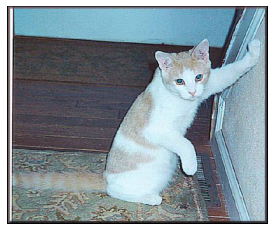

In [ ]:
# test_set에서 그림 불러오기
plt.imshow(plt.imread('/content/drive/MyDrive/test_set/test_set/cats/cat.4001.jpg'))
plt.axis('off')

# os.walk()
>* 하위의 폴더들을 for문으로 탐색할 수 있게 한다. 인자로 전달된 path에 대해 3개의 값이 있는 tuple을 넘겨준다.
>* first(root): dir과 files가 있는 path
>* second(dirs): root 아래에 있는 폴더들
>* third(files): root 아래에 있는 파일들
# os.path.join()
>* 인수에 전달된 2개의 문자열을 결합하여, 1개의 경로로 할 수있다.

https://codechacha.com/ko/python-walk-files/

In [ ]:
test_list = [] # test_set의 파일 경로들을 담은 리스트
test_target = []

for dirname, _, filenames in os.walk(test_path):
    #print(filenames)
    for filename in filenames:
        #print(filename)
        if(filename.endswith('jpg')): # 확장자가 jpg인 것만 담아주기
            if(filename[0] == 'c'):
                test_target.append(0)
            elif(filename[0] == 'd'):
                test_target.append(1)
            test_count = os.path.join(dirname, filename)
            test_list.append(test_count)

In [ ]:
train_list = []
train_target = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('jpg')):
            if(filename[0] == 'c'):
                train_target.append(0)
            elif(filename[0] == 'd'):
                train_target.append(1)
            train_count = os.path.join(dirname, filename)
            train_list.append(train_count)

(-0.5, 328.5, 499.5, -0.5)

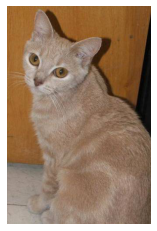

In [ ]:
plt.imshow(plt.imread(train_list[1]))
plt.axis('off')

# 경로에서 이미지 데이터 가져오기 (Try 1)

## PIL(pillow) 모듈 : 이미지 처리 모듈
>* Image 패키지
>* Image.open(path)를 통해 그림을 가져와서 numpy로 바꿀 수 있다. -> 너무 오래 걸림
>* https://ddolcat.tistory.com/690

(375, 499, 3)
(500, 329, 3)
(486, 358, 3)
(313, 432, 3)
(319, 375, 3)
(421, 405, 3)
(374, 500, 3)
(331, 500, 3)
(374, 500, 3)
(460, 499, 3)


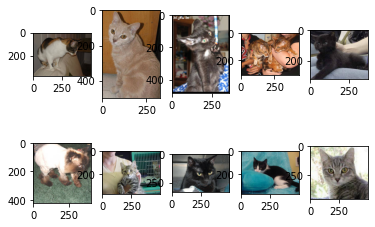

In [ ]:
# 이미지 10개 정도 train_set에서 순차적으로 골라서 shape 확인

fig, ax = plt.subplots(2, 5)

for i, jpg_path in enumerate(train_list):
    if(i == 10):
        break
    img = Image.open(jpg_path)
    ax[i // 5][i % 5].imshow(img)
    img_array = np.array(img)
    print(img_array.shape)

plt.show()

# 이미지마다 shape가 각각 다 다르다 -> 같게 해줄 필요가 있다.

In [ ]:
# 경로에서 PIL을 통해 Image를 가져와서 넘파이로 변환 후, train_set에 넣는 작업을 시도함

# >> 이 방식은 너무 오래 걸림
"""
train_set = []

for i, jpg_path in enumerate(train_list):
    print('counting... {}'.format(i))
    img = Image.open(jpg_path)
    img_array = np.array(img)
    train_set.append(img_array)

test_set = []

for i, jpg_path in enumerate(test_list):
    print('counting... {}'.format(i))
    img = Image.open(jpg_path)
    img_array = np.array(img)
    test_set.append(img_array)
"""

"\ntrain_set = []\n\nfor i, jpg_path in enumerate(train_list):\n    print('counting... {}'.format(i))\n    img = Image.open(jpg_path)\n    img_array = np.array(img)\n    train_set.append(img_array)\n\ntest_set = []\n\nfor i, jpg_path in enumerate(test_list):\n    print('counting... {}'.format(i))\n    img = Image.open(jpg_path)\n    img_array = np.array(img)\n    test_set.append(img_array)\n"

# 경로에서 이미지 데이터 가져오기 (Try 2)
##Keras로 이미지 데이터 불러오기

>* image.load_img(경로 문자열, 사이즈)
>* 불러오면서 resize까지 시켜서 편함

https://m.blog.naver.com/PostView.naver?isHttpsRedirect=true&blogId=baek2sm&logNo=221400912923

In [ ]:
# get Data from Path and Transform(Resize)
# 이것도 오래 걸림

from tensorflow.keras.preprocessing import image

train_set = []

for i, f in enumerate(train_list):
    img = image.load_img(f, target_size = (224, 224, 3)) # 반환형 <class 'PIL.Image.Image'>
    print('count {}'.format(i))
    img_np = np.array(img)
    train_set.append(img_np)

In [ ]:
test_set = []

for f in test_list:
    img = image.load_img(f, target_size=(224, 224, 3))
    img_np = np.array(img)
    test_set.append(img)

# Pytorch ImageFolder
>* cat이랑 dog split하는 방법 찾다가 pytorch ImageFolder 사용하는 법
>* => 파일 받아올 때 해결해버림 (안 씀)

https://ndb796.tistory.com/373

https://dacon.io/codeshare/4750

## 쓴 방법
>* 애초에 데이터 경로를 받아오는 train_list, test_list에서 받는 과정에 경로가 'c'로 시작하면 target에 0을, 'd'로 시작하면 target에 1을 넣도록 처리해뒀다.

In [ ]:
# train, validation SPLIT

from sklearn.model_selection import train_test_split

train_set, val_set, train_target, val_target = train_test_split(
    train_set, train_target, test_size=0.02, random_state=42
)

# Modeling

>* 데이터를 이 파일에서 따로 가져와서 모델은 다른 파일에서 돌릴 계획

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding = 'same', input_shape=(224, 224, 3)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding = 'same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

# 에러 난 부분
>* train을 시키는 데이터나 타깃의 type이 numpy가 아닌 list로 들어가서 났던 오류 타입 변환해서 넣어주면 된다.

Failed to find data adapter that can handle input: <class 'numpy.ndarray'>, (<class 'list'> containing values of types {"<class 'int'>"})

=> https://stackoverflow.com/questions/58682026/failed-to-find-data-adapter-that-can-handle-input-class-numpy-ndarray-cl

=> list 형태의 data_set을 numpy형태로 변환이 필요하다.

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [ ]:
%%time

train_set = np.array(train_set)
train_target = np.array(train_target)
test_set = np.array(test_set)
test_target = np.array(test_target)

history = model.fit(train_set, train_target, epochs=20, 
                    validation_data=(val_set, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

# 할 일
>* 경로 데이터를 이 파일에서 가져와서 다른 파일에서 모델링을 할 수는 없을까?